# SLD pipeline on Kaggle: component classifier, then full-sheet detection and graph recovery

One notebook, two stages, both models kept under `/kaggle/working/sld_pipeline/models` so a later session can reuse them.

**Stage A – component classifier** (`src/Object Detection/Component Training/`): 66 symbol types on isolated crops. Scores so far: 99.8 % val, 93 % on the unseen-style printed test set.

**Stage B – full sheets** (`src/Object Detection/SLD Training/`): YOLOv8 finds symbols, junctions and text on a whole drawing; `wires.py` traces the wires into nets and edges; the Stage A classifier re-labels every detected symbol crop.

**Before running**: GPU on, Internet on, attach three datasets: component crops `anayedeshan/sld-component-dataset` (`manifest.jsonl`, `images/train`), full sheets `anayedeshan/sld-full-sheets` (`data.yaml`, `images/`, `labels/`, `graphs/`), and printed test crops `anayedeshan/sld-computer-made-test`. From this PC, `python src/kaggle_runner/run.py sld-pipeline` pushes this notebook and attaches those three. Every cell is safe to re-run after a restart.

In [1]:
# imports
import json, os, shutil, subprocess, sys, zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from IPython.display import Image as IPyImage, display

## Paths

In [2]:
REPO_URL = "https://github.com/ishuu19/Single-Line-Diagram-and-Energy-Mapping.git"
REPO = Path("/kaggle/working/Single-Line-Diagram-and-Energy-Mapping")
COMP_DIR = REPO / "src" / "Object Detection" / "Component Training"
SLD_DIR = REPO / "src" / "Object Detection" / "SLD Training"
SAVE_DIR = Path("/kaggle/working/sld_pipeline")      # survives "Save Version": models + outputs of both stages
INPUT = Path("/kaggle/input")

COMP_EPOCHS = 15     # Stage A; 3 for a smoke run. 0 = skip training and reuse a saved model
SLD_EPOCHS = 60      # Stage B; 2 for a smoke run. 0 = skip training and reuse saved weights

## Helpers

In [3]:
def sh(*cmd, cwd=None):
    r = subprocess.run(cmd, cwd=cwd, text=True, capture_output=True)
    return (r.stdout + r.stderr).strip()


def find_dir(marker):
    """First folder under /kaggle/input that contains `marker` (e.g. images/train or data.yaml)."""
    for hit in INPUT.rglob(marker.split("/")[-1]):
        root = hit
        for _ in marker.split("/"):
            root = root.parent
        if (root / marker).exists():
            return root
    return None


def mounted(slug):
    """Attached dataset root. Kaggle uses either of these mount points."""
    name = slug.split("/")[-1]
    for c in (INPUT / "datasets" / slug, INPUT / name):
        if c.exists():
            return c
    return None


def find_tree(marker, under=None):
    """Directory that contains `marker`, under one dataset or all of /kaggle/input."""
    base = under or INPUT
    if not base.exists():
        return None
    for hit in base.rglob(marker.split("/")[-1]):
        root = hit
        for _ in marker.split("/"):
            root = root.parent
        if (root / marker).exists():
            return root
    return None


def link(src, dest):
    dest.parent.mkdir(parents=True, exist_ok=True)
    if dest.is_symlink() or dest.exists():
        dest.unlink() if dest.is_symlink() else shutil.rmtree(dest)
    os.symlink(src, dest, target_is_directory=True)


def restore(saved_sub, dest, pattern):
    """Copy models saved by an earlier session back into the repo folder."""
    src = SAVE_DIR / saved_sub
    if src.exists():
        dest.mkdir(parents=True, exist_ok=True)
        for f in src.glob(pattern):
            if not (dest / f.name).exists():
                shutil.copy(f, dest / f.name)


def keep(src, saved_sub):
    if src.exists():
        shutil.copytree(src, SAVE_DIR / saved_sub, dirs_exist_ok=True)


def sh_live(*cmd, cwd=None):
    """Like sh(), but streams output live, byte by byte, so tqdm's \r progress bars redraw in place."""
    import codecs
    proc = subprocess.Popen(cmd, cwd=cwd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    dec = codecs.getincrementaldecoder("utf-8")(errors="replace")
    out = []
    while b := proc.stdout.read(1):
        ch = dec.decode(b)
        print(ch, end="", flush=True)
        out.append(ch)
    proc.wait()
    return "".join(out)


## Repo

In [4]:
if (REPO / ".git").is_dir():
    sh("git", "pull", "--ff-only", cwd=REPO)
else:
    sh("git", "clone", "-q", REPO_URL, str(REPO))
assert (COMP_DIR / "train.py").exists() and (SLD_DIR / "train_sld.py").exists()

In [5]:
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "keras-tuner", "ultralytics", "scikit-image", "networkx"], check=True);

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 4.6 MB/s eta 0:00:00


# Stage A – component classifier
Scripts are run as subprocesses so Stage A's `config.py` never collides with Stage B's.

In [6]:
def crop_root():
    """Folder that has both manifest.jsonl and images/train.

    The sheet set also has images/train, so that marker alone picks the wrong dataset.
    Crops are nested: sld-component-dataset/component-symbols/.
    """
    bases = [
        INPUT / "datasets" / "anayedeshan" / "sld-component-dataset",
        INPUT / "sld-component-dataset",
        INPUT / "datasets" / "sld-component-dataset",
    ]
    bases.extend(p for p in INPUT.iterdir() if p.is_dir() and "component" in p.name)
    seen = set()
    for base in bases:
        if not base.is_dir() or base in seen:
            continue
        seen.add(base)
        for root in (base, base / "component-symbols"):
            if (root / "manifest.jsonl").is_file() and (root / "images" / "train").is_dir():
                return root
    return None

CROPS = crop_root()
assert CROPS is not None, (
    "component crops not found. /kaggle/input contains: "
    + ", ".join(p.name for p in INPUT.iterdir())
)
print(CROPS)
link(CROPS, REPO / "Data" / "component-symbols")

In [7]:
# printed held-out test crops: attached dataset, else the repo zip
printed = REPO / "Data" / "component-symbols-test-printed"
if not (printed / "images" / "test").is_dir():
    test_ds = mounted("anayedeshan/sld-computer-made-test")
    src = None
    if test_ds:
        src = test_ds if (test_ds / "images" / "test").is_dir() else find_tree("images/test", test_ds)
    if src:
        link(src, printed)
    else:
        zip_path = REPO / "Data" / "component-symbols-test-printed.zip"
        if zip_path.exists():
            with zipfile.ZipFile(zip_path) as z:
                z.extractall(REPO / "Data" if z.namelist()[0].startswith("component-symbols-test-printed/") else printed)

In [8]:
restore("models/component", COMP_DIR / "models", "*.keras")
restore("models/component", COMP_DIR / "models", "*.json")
sorted(p.name for p in (COMP_DIR / "models").glob("*"))

['notebook_best.keras']

### Data check

In [9]:
print(sh(sys.executable, "-c", "from data import load_datasets; tr, va, cn, _ = load_datasets(); print(len(cn), 'classes |', int(tr.cardinality()), 'train batches |', int(va.cardinality()), 'val batches')", cwd=COMP_DIR).splitlines()[-1])

I0000 00:00:1790505985.530224     121 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


### Augmented samples

In [ ]:
sh(sys.executable, "-c", "import matplotlib\nmatplotlib.use('Agg')\nimport matplotlib.pyplot as plt\nfrom pathlib import Path\nfrom data import load_datasets\n\nPath('outputs').mkdir(exist_ok=True)\ntrain_ds, _, class_names, _ = load_datasets(mixup_alpha=0.2)\nimages, _ = next(iter(train_ds))\nimages = images.numpy()[:10]\n\nfig, axes = plt.subplots(2, 5, figsize=(15, 6))\nfor ax, img in zip(axes.flat, images):\n    ax.imshow(img.squeeze(), cmap='gray')\n    ax.axis('off')\nfig.suptitle('Stage A: augmented training samples (mixup)')\nplt.tight_layout()\nplt.savefig('outputs/augmented_sample.png', dpi=120)\n", cwd=COMP_DIR)
display(IPyImage(str(COMP_DIR / "outputs" / "augmented_sample.png"), width=700))

### Train

In [ ]:
if COMP_EPOCHS:
    sh_live(sys.executable, "-u", "train.py", "--epochs", str(COMP_EPOCHS), cwd=COMP_DIR)

### Evaluate

In [11]:
have = {p.stem for p in (COMP_DIR / "models").glob("*.keras")}
COMP_TAG = next(t for t in ("custom_best", "custom", "notebook_best") if t in have)
COMP_TAG

'custom_best'

In [ ]:
for split in ("val", "printed-test"):
    print(split, sh(sys.executable, "evaluate.py", "--model", COMP_TAG, "--split", split, cwd=COMP_DIR).splitlines()[:5])

val ['{', '  "clean": 0.998,', '  "tta": 0.998,', '  "degraded": 0.996', '}']
printed-test ['{', '  "clean": 0.9242424242424242,', '  "tta": 0.9242424242424242,', '  "degraded": 0.9191919191919192', '}']


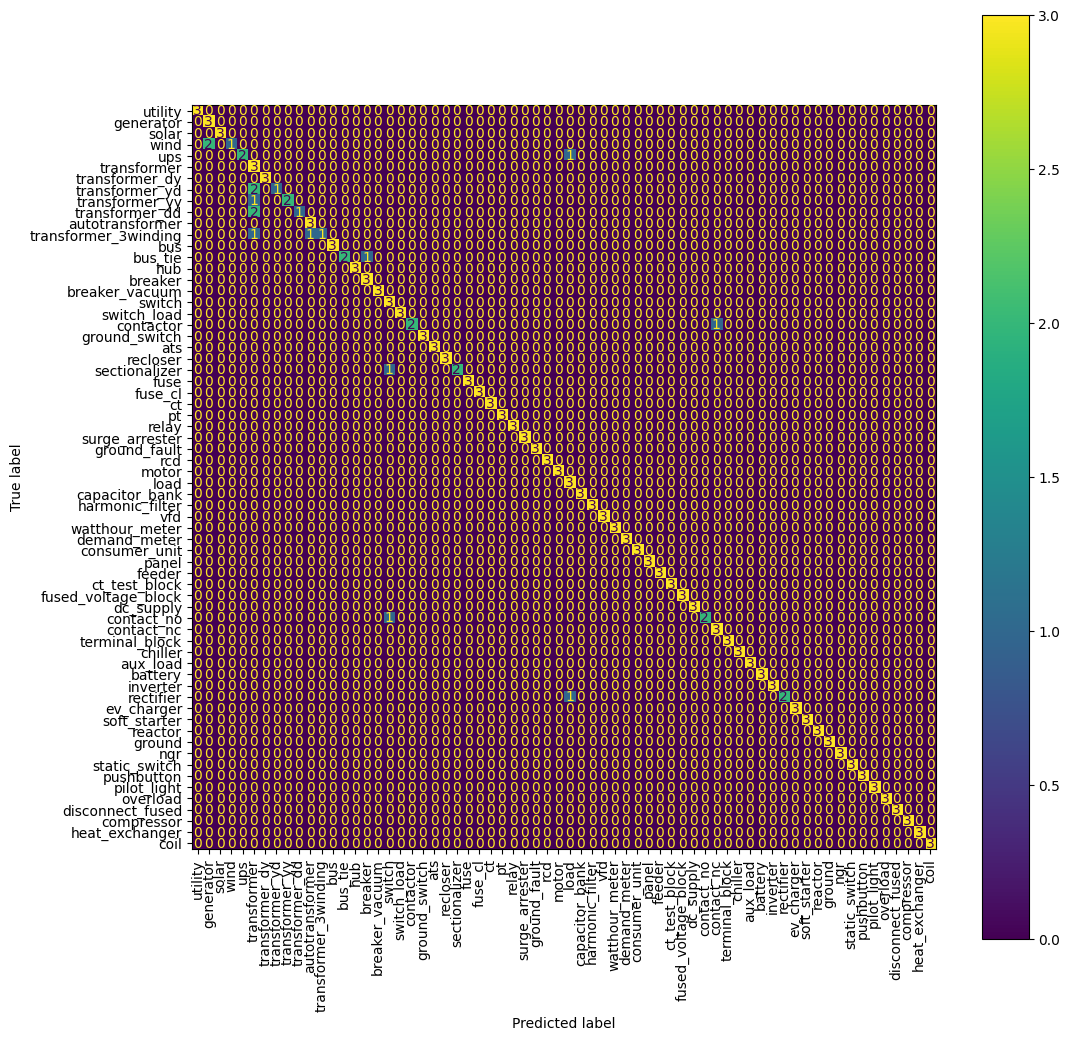

In [14]:
display(IPyImage(str(COMP_DIR / "outputs" / f"{COMP_TAG}_printed_test_confusion_matrix.png"), width=700))

In [15]:
keep(COMP_DIR / "models", "models/component")
keep(COMP_DIR / "outputs", "outputs/component")

# Stage B – full sheets

In [ ]:
os.chdir(SLD_DIR)
sys.path.insert(0, str(SLD_DIR))
import config
from sld_data import load_classes, sheet_ids, image_path, load_graph, gt_detections
from wires import trace
from graph_eval import score_sheet, summarise, oracle_prediction
from train_sld import train, resolve_data_yaml
from predict_graph import load_detector, predict_sheet
from reclassify import load_classifier, reclassify
from viz import show_graph

In [26]:
sheets_ds = mounted("anayedeshan/sld-full-sheets")
SHEETS = None
if sheets_ds:
    for c in (sheets_ds / "sld-sheets", sheets_ds):
        if (c / "data.yaml").exists() and (c / "graphs").is_dir():
            SHEETS = c
            break
    if SHEETS is None:
        hit = find_tree("data.yaml", sheets_ds)
        if hit and (hit / "graphs").is_dir():
            SHEETS = hit
if SHEETS is None:
    hit = find_tree("data.yaml")
    if hit and (hit / "graphs").is_dir():
        SHEETS = hit
assert SHEETS, "sld-sheets not found (anayedeshan/sld-full-sheets)"
link(SHEETS, config.SHEETS_DIR)
classes = load_classes()
len(classes), {s: len(sheet_ids(s)) for s in ("train", "val", "test")}

(23, {'train': 1277, 'val': 160, 'test': 71})

In [27]:
restore("models/sld", config.MODEL_DIR, "*.pt")

### Data check

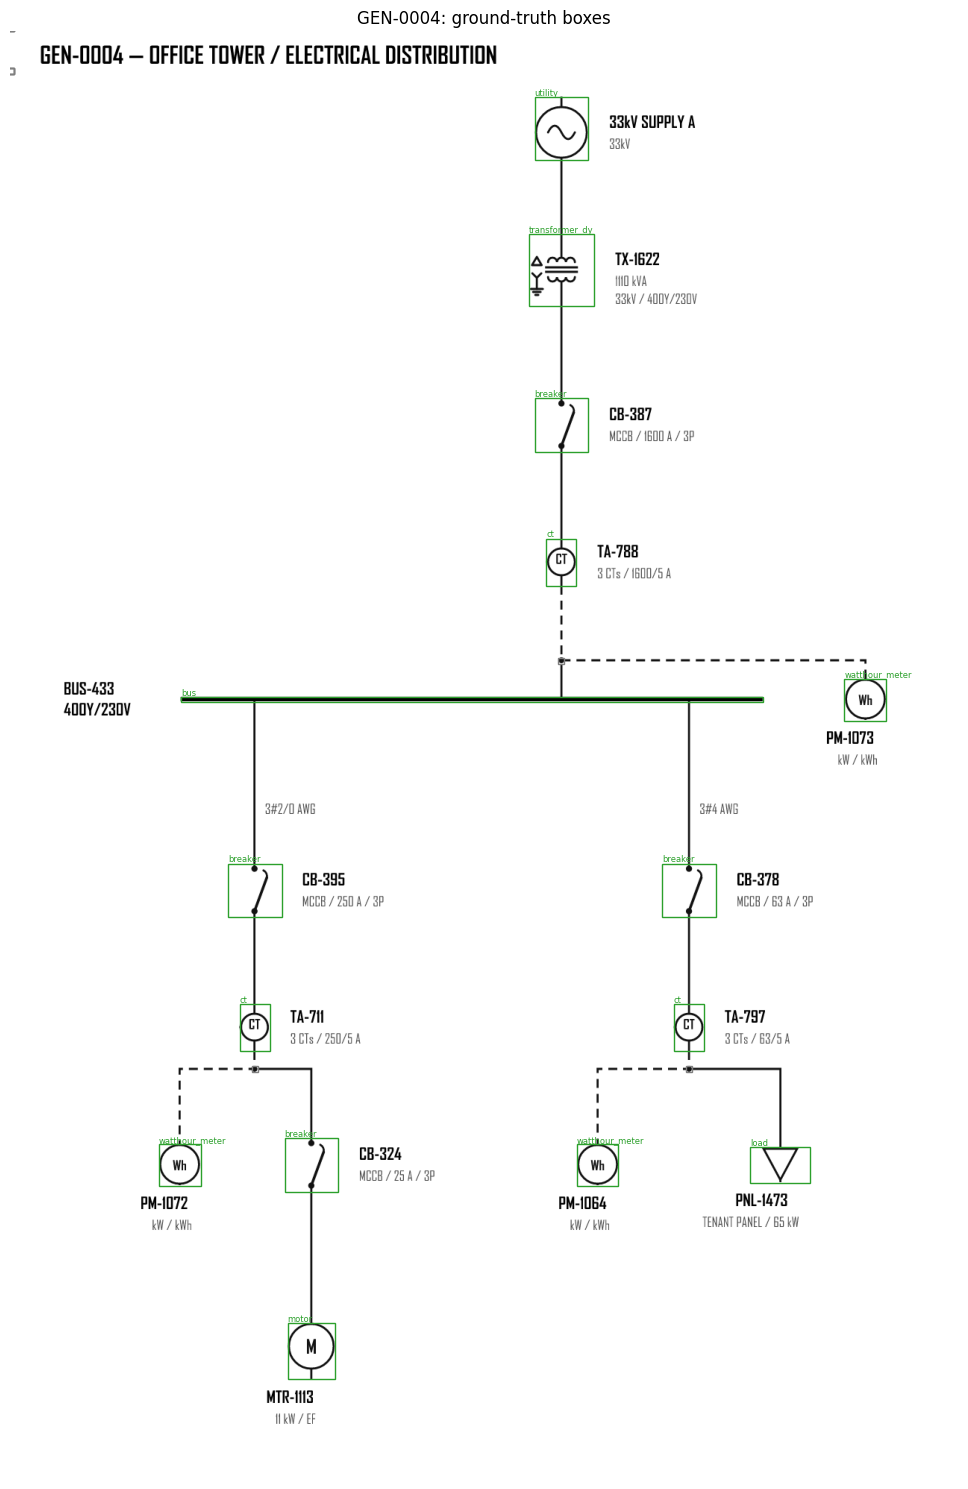

In [28]:
sid = sheet_ids("val")[0]
image = Image.open(image_path(sid, "val"))
show_graph(image, {"symbols": gt_detections(load_graph(sid), classes), "edges": []}, f"{sid}: ground-truth boxes");

### Wire tracer with ground-truth boxes

In [29]:
summarise([score_sheet(*oracle_prediction(s, "val", classes)) for s in sheet_ids("val")[:20]])

{'sheets': 20,
 'node_precision': 1.0,
 'node_recall': 1.0,
 'edge_precision': 0.9866220735785953,
 'edge_recall': 0.8600583090379009,
 'edge_type_accuracy': 1.0,
 'net_jaccard': 0.9134484107162677}

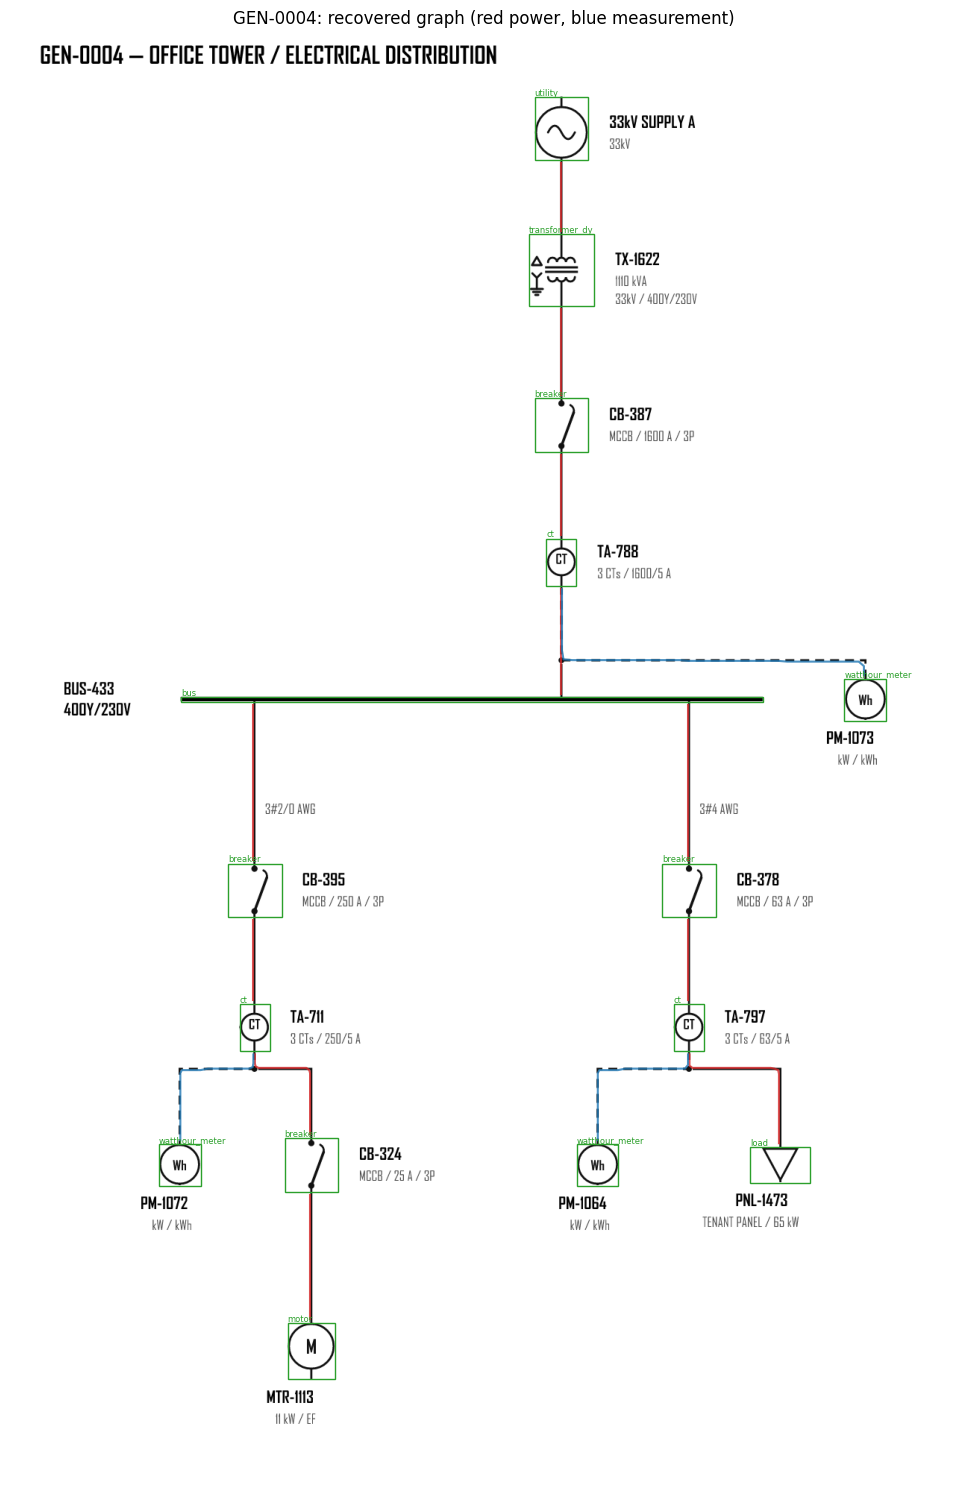

In [30]:
graph, result = oracle_prediction(sid, "val", classes)
show_graph(image, result, f"{sid}: recovered graph (red power, blue measurement)");

### Train the detector

### Augmented samples

In [ ]:
from ultralytics.data.build import build_yolo_dataset
from ultralytics.data.utils import check_det_dataset
from ultralytics.cfg import get_cfg
from ultralytics.utils import DEFAULT_CFG

# same augmentation settings as train_sld.train()
hyp = get_cfg(DEFAULT_CFG)
for k, v in dict(
    fliplr=0.0, flipud=0.0, degrees=0.0, scale=0.2, mosaic=1.0, hsv_h=0.0, hsv_s=0.0, hsv_v=0.2,
    translate=0.1, shear=2.0, perspective=0.0005, mixup=0.1, copy_paste=0.1,
).items():
    setattr(hyp, k, v)
hyp.imgsz = config.IMG_SIZE

data_dict = check_det_dataset(str(resolve_data_yaml(config.DATA_YAML, SAVE_DIR / "data.yaml")))
aug_ds = build_yolo_dataset(hyp, data_dict["train"], batch=10, data=data_dict, mode="train")

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, i in zip(axes.flat, range(10)):
    ax.imshow(aug_ds[i]["img"].permute(1, 2, 0).numpy())
    ax.axis("off")
fig.suptitle("Stage B: augmented training samples")
plt.tight_layout()
plt.show()

In [31]:
from ultralytics.utils import LOGGER
if not getattr(LOGGER, "_sld_quiet", False):
    _info = LOGGER.info
    def _info_quiet(msg, *args, **kwargs):
        text = msg % args if args and isinstance(msg, str) else msg
        if not isinstance(text, str) or "duplicate labels removed" not in text:
            return _info(msg, *args, **kwargs)
        images = boxes = 0
        split = "scan"
        for line in text.splitlines():
            if "duplicate labels removed" not in line:
                continue
            images += 1
            plain = "".join(part.split("m", 1)[-1] for part in line.split("\x1b"))
            split = plain.split(":", 1)[0].strip() or split
            tail = plain.rsplit(":", 1)[-1].strip().split()
            if tail and tail[0].isdigit():
                boxes += int(tail[0])
        _info(f"{split}: {images} images, {boxes} duplicate labels removed")
    LOGGER.info = _info_quiet
    LOGGER._sld_quiet = True

if SLD_EPOCHS:
    # extra augmentation on top of train_sld.py defaults: mild translate/shear/mixup/copy-paste
    WEIGHTS = train(
        epochs=SLD_EPOCHS, project=SAVE_DIR / "runs",
        translate=0.1, shear=2.0, perspective=0.0005, mixup=0.1, copy_paste=0.1,
    )
else:
    WEIGHTS = next(config.MODEL_DIR.glob("sld_*.pt"))
WEIGHTS

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.163 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/sld_pipeline/runs/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fr

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


       2/60      7.37G     0.4903      0.408     0.8472        391       1280: 100% ━━━━━━━━━━━━ 160/160 2.6it/s 1:020.3sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.9it/s 3.4s.3ss
                   all        160       9760       0.83       0.75      0.766      0.669

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/60      7.25G     0.4391     0.3585     0.8263        361       1280: 100% ━━━━━━━━━━━━ 160/160 2.6it/s 1:020.3sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.7it/s 3.8s.4ss
                   all        160       9760      0.883      0.775      0.774      0.694

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/60      7.25G     0.4093     0.3364     0.8199        376       1280: 100% ━━━━━━━━━━━━ 160/160 2.5it/s 1:030.3sss
                 Class     Ima

PosixPath('/kaggle/working/Single-Line-Diagram-and-Energy-Mapping/src/Object Detection/SLD Training/models/sld_yolov8s.pt')

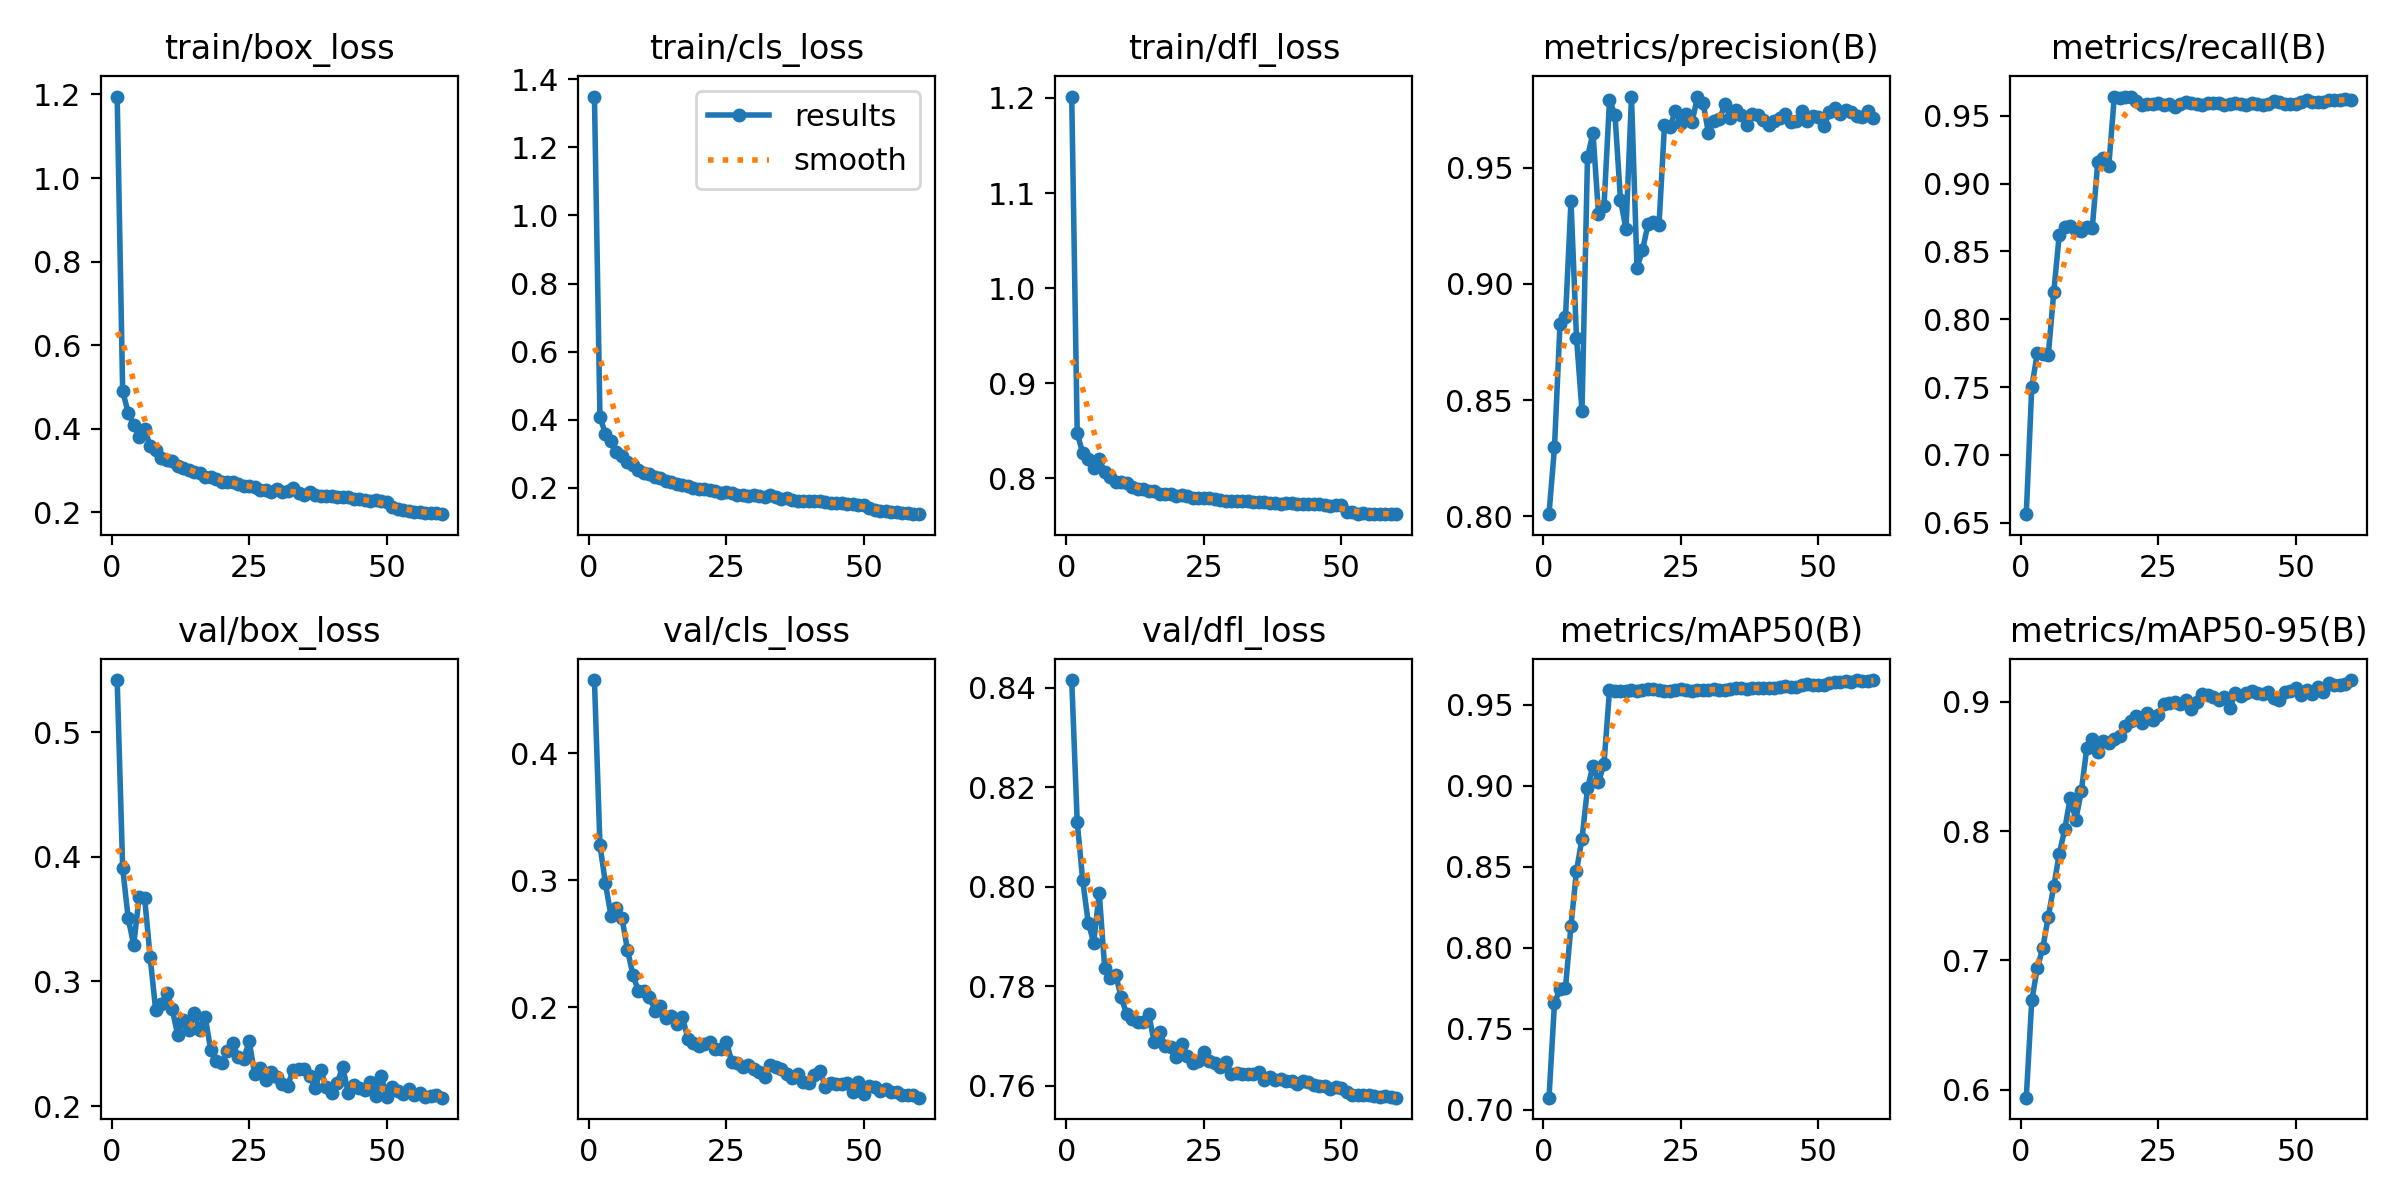

In [33]:
if SLD_EPOCHS:
    display(Image.open(SAVE_DIR / "runs" / "sld" / "results.png"))

### Detector metrics on the test split

In [34]:
from ultralytics import YOLO
from train_sld import resolve_data_yaml
data_yaml = resolve_data_yaml(config.DATA_YAML, SAVE_DIR / "data.yaml")
m = YOLO(str(WEIGHTS)).val(data=str(data_yaml), split="test", imgsz=config.IMG_SIZE, plots=False, verbose=False)
{"mAP50": round(float(m.box.map50), 3), "mAP50-95": round(float(m.box.map), 3)}

Ultralytics 8.4.163 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 11,134,485 parameters, 0 gradients, 28.5 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 1.1±1.0 ms, read: 23.5±3.6 MB/s, size: 128.0 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /kaggle/input/datasets/anayedeshan/sld-diagram-and-label-data/sld-sheets/labels/test... 71 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 71/71 243.7it/s 0.3s0.1s
val: /kaggle/input/datasets/anayedeshan/sld-diagram-and-label-data/sld-sheets/images/test/GEN-0025.png: 3 duplicate labels removed
val: /kaggle/input/datasets/anayedeshan/sld-diagram-and-label-data/sld-sheets/images/test/GEN-0030.png: 4 duplicate labels removed
val: /kaggle/input/datasets/anayedeshan/sld-diagram-and-label-data/sld-sheets/images/test/GEN-0045.png: 1 duplicate labels removed
val: /kaggle/input/data

{'mAP50': 0.96, 'mAP50-95': 0.932}

### Detector + tracer, then the Stage A classifier re-labels each symbol crop

In [35]:
detector = load_detector(WEIGHTS)
classifier = load_classifier(COMP_DIR / "models" / f"{COMP_TAG}.keras")
test_ids = sheet_ids("test")

I0000 00:00:1790514850.405946      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 8552 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790514850.408308      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13754 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [36]:
def recover(sid, use_classifier=True):
    img = Image.open(image_path(sid, "test"))
    result, graph = predict_sheet(detector, img, classes, sid)
    if use_classifier:
        reclassify(img, result["symbols"], classifier)
    return img, result, graph

In [37]:
rows_det = [score_sheet(load_graph(s), recover(s, use_classifier=False)[1]) for s in test_ids]
rows_clf = [score_sheet(load_graph(s), recover(s)[1]) for s in test_ids]
{"detector only": summarise(rows_det), "detector + classifier": summarise(rows_clf)}

{'detector only': {'sheets': 71,
  'node_precision': 1.0,
  'node_recall': 0.9481865284974094,
  'edge_precision': 0.8615241635687733,
  'edge_recall': 0.72421875,
  'edge_type_accuracy': 1.0,
  'net_jaccard': 0.9351986580935273},
 'detector + classifier': {'sheets': 71,
  'node_precision': 1.0,
  'node_recall': 0.9481865284974094,
  'edge_precision': 0.8615241635687733,
  'edge_recall': 0.72421875,
  'edge_type_accuracy': 1.0,
  'net_jaccard': 0.9351986580935273}}

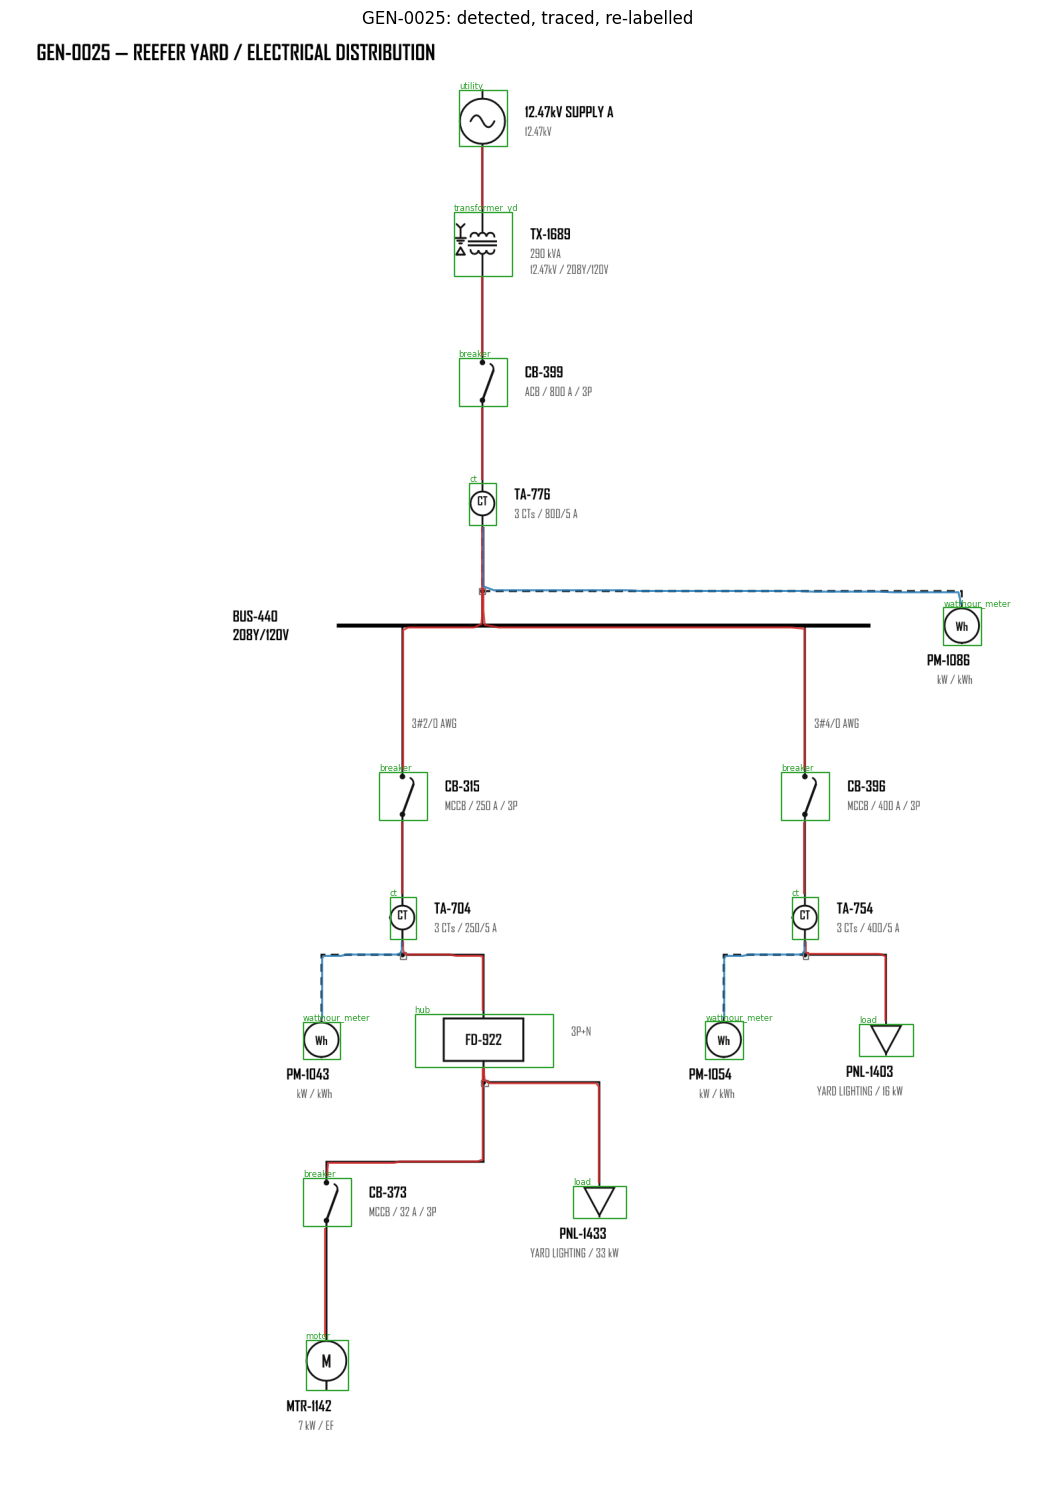

In [38]:
img, result, pred_graph = recover(test_ids[0])
show_graph(img, result, f"{test_ids[0]}: detected, traced, re-labelled");

### Labelled test sheets: what each symbol was classified as
Every detected symbol is boxed and tagged on the drawing with its final class (Stage A label) and confidence. Boxes are coloured per class; a tag ending in `*` means the classifier overrode the detector's label. Images are also saved to `outputs/labelled_test/`.

In [ ]:
from collections import Counter
from matplotlib import colormaps
from config import JUNCTION_CLASS, TEXT_CLASS

N_LABELLED = 4   # sheets to draw
LABEL_DIR = config.OUTPUT_DIR / "labelled_test"
LABEL_DIR.mkdir(parents=True, exist_ok=True)

def show_labelled(img, result, title, save_to=None):
    syms = [d for d in result["symbols"] if d["type"] not in (JUNCTION_CLASS, TEXT_CLASS)]
    cmap = colormaps["tab20"]
    color_of = {t: cmap(i % 20) for i, t in enumerate(sorted({d["type"] for d in syms}))}
    fig, ax = plt.subplots(figsize=(16, 22))
    ax.imshow(np.asarray(img.convert("L")), cmap="gray")
    for e in result["edges"]:
        pts = np.array(e["polyline"])
        ax.plot(pts[:, 0], pts[:, 1], "-", lw=1, color="0.55", alpha=0.6)
    for d in syms:
        x0, y0, x1, y1 = d["bbox"]
        c = color_of[d["type"]]
        ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, lw=2, ec=c))
        changed = "type_detector" in d and d["type_detector"] != d["type"]
        tag = f'{d["type"]}{"*" if changed else ""} {d.get("type_conf", 0):.2f}'
        ax.text(x0, y0 - 4, tag, fontsize=10, color="white", weight="bold", va="bottom",
                bbox=dict(boxstyle="round,pad=0.15", fc=c, ec="none", alpha=0.9))
    counts = Counter(d["type"] for d in syms)
    ax.set_title(f"{title}  |  " + ", ".join(f"{n}x {t}" for t, n in counts.most_common()), fontsize=11)
    ax.axis("off")
    plt.tight_layout()
    if save_to:
        fig.savefig(save_to, dpi=130)
    plt.show()

for sid_ in test_ids[:N_LABELLED]:
    img_, res_, _ = recover(sid_)
    show_labelled(img_, res_, f"{sid_}: classified symbols", LABEL_DIR / f"{sid_}.png")


In [39]:
pred_graph["edges"][:5]

[{'id': 'E001',
  'source': 'N002',
  'target': 'N008',
  'relationship': 'power',
  'line_style': 'solid',
  'polyline': [[355.5, 88.0],
   [355.5, 89.0],
   [355.5, 90.0],
   [355.5, 91.0],
   [355.5, 92.0],
   [355.5, 93.0],
   [355.5, 94.0],
   [355.5, 95.0],
   [355.5, 96.0],
   [355.5, 97.0],
   [355.5, 98.0],
   [355.5, 99.0],
   [355.5, 100.0],
   [355.5, 101.0],
   [355.5, 102.0],
   [355.5, 103.0],
   [355.5, 104.0],
   [355.5, 105.0],
   [355.5, 106.0],
   [355.5, 107.0],
   [355.5, 108.0],
   [355.5, 109.0],
   [355.5, 110.0],
   [355.5, 111.0],
   [355.5, 112.0],
   [355.5, 113.0],
   [355.5, 114.0],
   [355.5, 115.0],
   [355.5, 116.0],
   [355.5, 117.0],
   [355.5, 118.0],
   [355.5, 119.0],
   [355.5, 120.0],
   [355.5, 121.0],
   [355.5, 122.0],
   [355.5, 123.0],
   [355.5, 124.0],
   [355.5, 125.0],
   [355.5, 126.0],
   [355.5, 127.0],
   [355.5, 128.0],
   [355.5, 129.0],
   [355.5, 130.0],
   [355.5, 131.0],
   [355.5, 132.0],
   [355.5, 133.0],
   [355.5, 133.0]]

## Save both stages

In [40]:
config.OUTPUT_DIR.mkdir(exist_ok=True)
(config.OUTPUT_DIR / "graph_pred_test.json").write_text(json.dumps({
    "detector": summarise(rows_det), "detector+classifier": summarise(rows_clf), "sheets": dict(zip(test_ids, rows_clf))}, indent=1))
keep(config.MODEL_DIR, "models/sld")
keep(config.OUTPUT_DIR, "outputs/sld")
sorted(str(p.relative_to(SAVE_DIR)) for p in (SAVE_DIR / "models").rglob("*") if p.is_file())

['models/component/class_names.json',
 'models/component/custom.keras',
 'models/component/custom_best.keras',
 'models/component/notebook_best.keras',
 'models/sld/sld_yolov8s.pt']

## Download to your PC (models and outputs only)

Bundles everything under `SAVE_DIR` (component + SLD models, metrics JSON, plots) and this notebook. **No** crop or sheet datasets. Click the link, or use Kaggle **Output** after **Save Version**. Unzip into `src/Object Detection/SLD Training/Results/` in the repo.

In [41]:
BUNDLE_DIR = Path("/kaggle/working/sld_pipeline_artifacts")
BUNDLE_ZIP = Path("/kaggle/working/sld_pipeline_artifacts.zip")
if BUNDLE_DIR.exists():
    shutil.rmtree(BUNDLE_DIR)
BUNDLE_DIR.mkdir()

In [42]:
for sub in ("models", "outputs"):
    src = SAVE_DIR / sub
    if src.exists():
        shutil.copytree(src, BUNDLE_DIR / sub)

In [43]:
runs_sld = SAVE_DIR / "runs" / "sld"
if runs_sld.exists():
    shutil.copytree(runs_sld, BUNDLE_DIR / "runs" / "sld")

In [45]:
nb_repo = SLD_DIR / "notebooks" / "kaggle_sld_pipeline.ipynb"
if nb_repo.exists():
    shutil.copy(nb_repo, BUNDLE_DIR / "kaggle_sld_pipeline.ipynb")
for nb in Path("/kaggle/working").glob("*.ipynb"):
    if "sld" in nb.stem.lower() and nb.name != "kaggle_sld_pipeline.ipynb":
        shutil.copy(nb, BUNDLE_DIR / nb.name)
        break

In [46]:
if BUNDLE_ZIP.exists():
    BUNDLE_ZIP.unlink()
with zipfile.ZipFile(BUNDLE_ZIP, "w", zipfile.ZIP_DEFLATED) as zf:
    for path in BUNDLE_DIR.rglob("*"):
        if path.is_file():
            zf.write(path, path.relative_to(BUNDLE_DIR))

In [47]:
from IPython.display import FileLink, display

files = sorted(p.as_posix() for p in BUNDLE_DIR.rglob("*") if p.is_file())
print(f"{len(files)} files, {BUNDLE_ZIP.stat().st_size / 1e6:.1f} MB")
for line in files[:40]:
    print(" ", line)
if len(files) > 40:
    print(f"  ... and {len(files) - 40} more")
display(FileLink(str(BUNDLE_ZIP), result_html_suffix=" — download zip"))

45 files, 135.9 MB
  /kaggle/working/sld_pipeline_artifacts/kaggle_sld_pipeline.ipynb
  /kaggle/working/sld_pipeline_artifacts/models/component/class_names.json
  /kaggle/working/sld_pipeline_artifacts/models/component/custom.keras
  /kaggle/working/sld_pipeline_artifacts/models/component/custom_best.keras
  /kaggle/working/sld_pipeline_artifacts/models/component/notebook_best.keras
  /kaggle/working/sld_pipeline_artifacts/models/sld/sld_yolov8s.pt
  /kaggle/working/sld_pipeline_artifacts/outputs/component/custom_best_printed_test_confusion_matrix.png
  /kaggle/working/sld_pipeline_artifacts/outputs/component/custom_best_printed_test_metrics.json
  /kaggle/working/sld_pipeline_artifacts/outputs/component/custom_best_val_confusion_matrix.png
  /kaggle/working/sld_pipeline_artifacts/outputs/component/custom_best_val_metrics.json
  /kaggle/working/sld_pipeline_artifacts/outputs/component/custom_history.csv
  /kaggle/working/sld_pipeline_artifacts/outputs/component/custom_history.json
  /k

/kaggle/working/sld_pipeline_artifacts.zip